In [1]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. PATHS & DATASET CLASS
# ==========================================
BASE_KAGGLE_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset" 
TRAIN_DIR = f"{BASE_KAGGLE_DIR}/trimmed_train_data"
VAL_DIR = f"{BASE_KAGGLE_DIR}/trimmed_val_data"
TRAIN_JSON_PATH = f"{TRAIN_DIR}/processed_train_data.json"
VAL_JSON_PATH = f"{VAL_DIR}/processed_val_data.json"

class KaggleClothingDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = full_data["data"]
        self.top_5_categories = full_data.get("top_5_categories", [1, 8, 7, 2, 9])
        self.transform = transform
        self.img_dir = img_dir
        self.label_map = {cat_id: idx for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        full_image_path = os.path.join(self.img_dir, item["image_path"])
        
        try:
            image = Image.open(full_image_path).convert('RGB')
        except Exception:
            return torch.zeros((3, 224, 224)), torch.zeros(5)

        if self.transform:
            image = self.transform(image)

        target = torch.zeros(5, dtype=torch.float32)
        for cat_id in item["classification_labels"]:
            if cat_id in self.label_map:
                target[self.label_map[cat_id]] = 1.0

        return image, target

# ==========================================
# 2. TRANSFORMS & SPLITTING
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets into memory...")
train_dataset = KaggleClothingDataset(TRAIN_JSON_PATH, TRAIN_DIR, transform=train_transforms)
full_val_dataset = KaggleClothingDataset(VAL_JSON_PATH, VAL_DIR, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size

val_dataset, test_dataset = random_split(
    full_val_dataset, 
    [val_size, test_size], 
    generator=torch.Generator().manual_seed(42) 
)

BATCH_SIZE = 128  
NUM_WORKERS = 2  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset Splitting Complete! Batches of {BATCH_SIZE} ready.")

Loading datasets into memory...
✅ Dataset Splitting Complete! Batches of 128 ready.


In [2]:
import time # <-- Added for epoch timing
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. BUILD RESNET-50 FROM SCRATCH
# ==========================================
print("Loading BLANK ResNet-50 (No pre-trained weights)...")
# weights=None ensures complete random initialization (amnesia mode)
model_resnet_scratch = models.resnet50(weights=None)

# We DO NOT freeze any layers here because the entire network needs to learn from scratch

# Replace the final classification head for our 5 classes
num_features = model_resnet_scratch.fc.in_features
model_resnet_scratch.fc = nn.Linear(num_features, 5) 

# 🔥 THE DUAL-GPU MAGIC LINE
if torch.cuda.device_count() > 1:
    print(f"🔥 Turbo Mode Activated: Splitting work across {torch.cuda.device_count()} GPUs!")
    model_resnet_scratch = nn.DataParallel(model_resnet_scratch)

model_resnet_scratch = model_resnet_scratch.to(device)

# ==========================================
# 2. LOSS & OPTIMIZER (Multi-Label)
# ==========================================
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model_resnet_scratch.parameters(), lr=0.001)

# ==========================================
# 3. HIGH-SPEED TRAINING LOOP
# ==========================================
best_val_loss = float('inf')  
num_epochs = 17               

for epoch in range(num_epochs):
    epoch_start_time = time.time() # ⏱️ START THE CLOCK
    
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
    model_resnet_scratch.train()
    running_loss = 0.0
    
    train_bar = tqdm(train_loader, desc="Training")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet_scratch(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- Quick Validation Pass ---
    model_resnet_scratch.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet_scratch(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    epoch_end_time = time.time() # ⏱️ STOP THE CLOCK
    epoch_duration = epoch_end_time - epoch_start_time
    
    print(f"Epoch {epoch+1} Completed in {epoch_duration:.0f}s | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f" New best validation score! Auto-saving weights...")
        
        if isinstance(model_resnet_scratch, nn.DataParallel):
            torch.save(model_resnet_scratch.module.state_dict(), "resnet50_scratch_best.pth")
        else:
            torch.save(model_resnet_scratch.state_dict(), "resnet50_scratch_best.pth")

print("\n ResNet-50 (From Scratch) successfully trained on dual GPUs!")

print("\nSaving final epoch weights as a backup...")

# Keeps a backup of the absolute last epoch
if isinstance(model_resnet_scratch, nn.DataParallel):
    torch.save(model_resnet_scratch.module.state_dict(), "resnet50_scratch_last.pth")
else:
    torch.save(model_resnet_scratch.state_dict(), "resnet50_scratch_last.pth")

print("Training sequence completely finished!")

Using device: cuda
Loading BLANK ResNet-50 (No pre-trained weights)...
🔥 Turbo Mode Activated: Splitting work across 2 GPUs!

--- Epoch 1/17 ---


Training: 100%|██████████| 1127/1127 [26:38<00:00,  1.42s/it, loss=0.5075]


Epoch 1 Completed in 1716s | Train Loss: 0.5428 | Validation Loss: 0.5387
 New best validation score! Auto-saving weights...

--- Epoch 2/17 ---


Training: 100%|██████████| 1127/1127 [14:46<00:00,  1.27it/s, loss=0.4668]


Epoch 2 Completed in 957s | Train Loss: 0.4649 | Validation Loss: 0.4323
 New best validation score! Auto-saving weights...

--- Epoch 3/17 ---


...

Epoch 15 Completed in 1074s | Train Loss: 0.2201 | Validation Loss: 0.2660
 New best validation score! Auto-saving weights...

--- Epoch 16/17 ---


Training: 100%|██████████| 1127/1127 [16:31<00:00,  1.14it/s, loss=0.2628]


Epoch 16 Completed in 1072s | Train Loss: 0.2136 | Validation Loss: 0.2731

--- Epoch 17/17 ---


Training: 100%|██████████| 1127/1127 [16:42<00:00,  1.12it/s, loss=0.1799]


Epoch 17 Completed in 1085s | Train Loss: 0.2068 | Validation Loss: 0.2807

 ResNet-50 (From Scratch) successfully trained on dual GPUs!

Saving final epoch weights as a backup...
Training sequence completely finished!


Evaluating ResNet-50 (From Scratch) on the Test Set (Sigmoid Threshold = 0.5)...


Testing: 100%|██████████| 93/93 [01:58<00:00,  1.27s/it]



🚀 PROJECT METRICS (ResNet-50 Scratch)
Micro Precision: 0.8589
Micro Recall:    0.7884
Micro F1-Score:  0.8222
Macro F1-Score:  0.8010

Per-Category Breakdown:
                  precision    recall  f1-score   support

Short Sleeve Top       0.87      0.85      0.86      6298
        Trousers       0.88      0.87      0.87      4771
          Shorts       0.85      0.69      0.77      2048
 Long Sleeve Top       0.79      0.66      0.72      2907
           Skirt       0.86      0.73      0.79      3223

       micro avg       0.86      0.79      0.82     19247
       macro avg       0.85      0.76      0.80     19247
    weighted avg       0.86      0.79      0.82     19247
     samples avg       0.83      0.79      0.79     19247



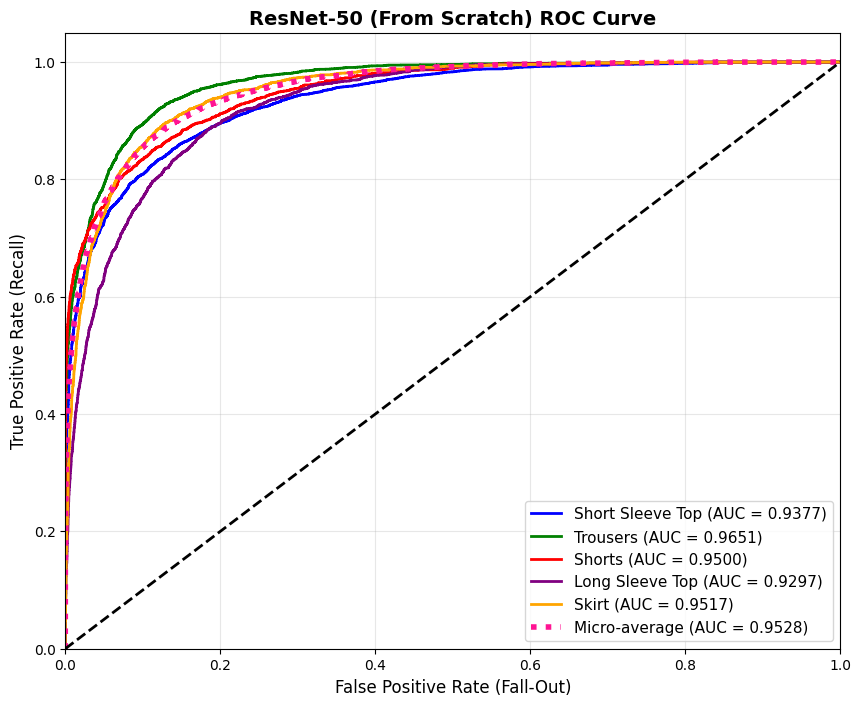

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc, accuracy_score
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ==========================================
# 4. METRICS & ROC EVALUATION SCRIPT
# ==========================================
print("Evaluating ResNet-50 (From Scratch) on the Test Set (Sigmoid Threshold = 0.5)...")

# Load the best weights to ensure we are evaluating the optimal epoch
state_dict = torch.load("resnet50_scratch_best.pth")
if isinstance(model_resnet_scratch, nn.DataParallel):
    model_resnet_scratch.module.load_state_dict(state_dict)
else:
    model_resnet_scratch.load_state_dict(state_dict)

model_resnet_scratch.eval()

all_preds = []
all_labels = []
all_probs = [] 

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_resnet_scratch(images)
        
        # Sigmoid converts raw logits to percentages
        probs = torch.sigmoid(outputs)
        # Apply the 0.5 threshold to get the hard 1s and 0s
        preds = (probs > 0.5).float()
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# --- CALCULATE METRICS ---
micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)

final_accuracy = accuracy_score(all_labels, all_preds)

print("\n" + "="*45)
print("🚀 PROJECT METRICS (ResNet-50 Scratch)")
print("="*45)
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")
print(f"Micro F1-Score:  {micro_f1:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("="*45)

categories = ["Short Sleeve Top", "Trousers", "Shorts", "Long Sleeve Top", "Skirt"] 
print("\nPer-Category Breakdown:")
print(classification_report(all_labels, all_preds, target_names=categories, zero_division=0))

# --- PLOT ROC CURVE ---
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate and plot ROC for each individual class
for i in range(5):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{categories[i]} (AUC = {roc_auc:.4f})')

# Calculate and plot the Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4, 
         label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Graph Formatting
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ResNet-50 (From Scratch) ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig("/kaggle/working/resnet50_scratch_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()